<img src='https://hammondm.github.io/hltlogo1.png' style="float:right">

LING 539<br>
Spring 2026<br>
Davo Acevedo-Cardona

## Kaggle Class Competition: Movie Review Classification

## Project Overview
**Task**: Classify text into three categories  
- (0) Not a movie/TV review  
- (1) Positive movie/TV review  
- (2) Negative movie/TV review  

**Dataset**: train.csv / test.csv  
**Goal**: Build a classification model optimized for **macro F1 score**, balancing performance across all classes

---

## What This Pipeline Does?
1. **Data Loading**: Reads training and test datasets from local `data/` folder  
2. **Exploration**: Analyzes class distribution and sample texts  
3. **Feature Extraction**: Converts raw text into numerical features using TF-IDF  
4. **Model Training**: Trains a classification model (Logistic Regression baseline)  
5. **Evaluation**: Computes macro F1 score on validation data  
6. **Prediction**: Generates predictions for Kaggle test set  
7. **Submission**: Outputs `submission.csv` 

---

## Libraries Used

- **Packages**: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`

---

# 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# 2. Load the data

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

# 3. Explore the Data

## 3.1 Knowing the data

In [3]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nMissing values in train:")
print(train.isna().sum())

print("\nMissing values in test:")
print(test.isna().sum())

print("\nLabel distribution:")
print(train["LABEL"].value_counts().sort_index())

print("\nLabel distribution (%):")
print((train["LABEL"].value_counts(normalize=True).sort_index() * 100).round(2))

Train columns:
['ID', 'TEXT', 'LABEL']

Test columns:
['ID', 'TEXT']

Missing values in train:
ID       0
TEXT     7
LABEL    0
dtype: int64

Missing values in test:
ID      0
TEXT    0
dtype: int64

Label distribution:
LABEL
0    32289
1    19139
2    18889
Name: count, dtype: int64

Label distribution (%):
LABEL
0    45.92
1    27.22
2    26.86
Name: proportion, dtype: float64


## 3.2 Label Distribution Plot

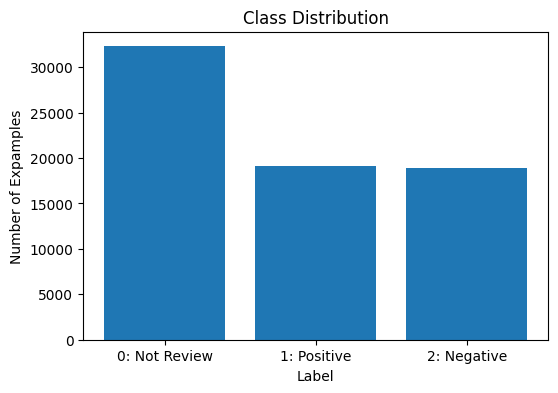

In [4]:
label_counts = train["LABEL"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.xlabel("Label")
plt.ylabel("Number of Expamples")
plt.title("Class Distribution")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["0: Not Review", "1: Positive", "2: Negative"]
)
plt.show()

### Observations

#### Class Distribution

The dataset shows some class imbalance:

- Class 0 (Not Review): ~46%
- Class 1 (Positive): ~27%
- Class 2 (Negative): ~27%

And indicates that "Class 0" is the dominant class and that positive and negative reviews are relatively balanced.

#### Implications for the Task

- The first thing would be applying a correction so the model is not biased toward predicting class 0.
-  Since the evaluation metric is **macro F1**, performance on all classes is equally important


#### Modeling Decisions

Based on this distribution:
- I will use `class_weight='balanced'` to mitigate class imbalance
- I will monitor per-class performance

## 3.3 Handle missing values

In [5]:
train["TEXT"] = train["TEXT"].fillna("")
test["TEXT"] = test["TEXT"].fillna("")

## 3.4 Sample Text Inspection

In [6]:
# "for" cycle to show examples from each class

for label in [0, 1, 2]:
    print(f"\n===== CLASS {label} EXAMPLES =====\n")
    samples = train[train["LABEL"] == label]["TEXT"].head(3)
    for i, text in enumerate(samples, 1):
        print(f"Example {i}:\n{text[:500]}\n")


===== CLASS 0 EXAMPLES =====

Example 1:
Carolyn Baker defines the niche of helping people prepare inwardly and in our relationships, for the obvious, huge challenges that face us all in the present and near future.

Example 2:
I was greatly dissappointed when I popped this game into my Xbox. The play was choppy, not smooth at all and far too slow. At times, the players looked cartoon-like. If I were you I would wait for NBA Inside Drive 2002, which comes out on January 22nd. This looks like a much better game and should prove to be so. People are saying that NBA Live 2002 is better than 2001. Its true, but not by much, plus, 2001 really really stunk! Wait for Inside Drive 2002!

Example 3:
Superbly researched.  Cogent presentation of the third Hundred Days.  Only FDR could convert America from isolation to mobilization so swiftly.


===== CLASS 1 EXAMPLES =====

Example 1:
Just getting released from a six month drug rehabilitation program and having served his time for dealing cards 

### Text Pattern Observations

#### Class 0 (Not Review)

The examples show that class 0 is highly diverse and includes:
- General informational text (e.g., historical or academic descriptions)
- Product/game reviews (not related to movies or TV)
- General commentary or descriptive writing

This suggests that class 0 is a **heterogeneous class**, making it harder to model.

---

#### Class 1 (Positive Reviews)

Positive reviews tend to include:
- Explicit references to movies or TV shows (e.g., "episode", "film")
- Subjective language expressing enjoyment
- Descriptive commentary about plot, characters, or acting

---

#### Class 2 (Negative Reviews)

Negative reviews show:
- Strong subjective and emotional language
- Criticism of plot, acting, or overall quality
- Often aggressive or exaggerated tone

---

#### Insights

1. The objective will be distinguishing:
   - movie/TV reviews vs non-reviews

2. Class 0 is not "neutral text":
   - it includes other types of reviews (e.g., video games)
   - it includes unrelated descriptive text

3. Sentiment classification (1 vs 2) is easier than:
   - detecting whether the text is a movie/TV review

---

# 4. Modeling the Data

In [7]:
#Prepare the data

X = train["TEXT"]
y = train["LABEL"]

#Train split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (56253,)
Validation size: (14064,)


# 5. TF-IDF and Logistic Regression

## 5.1 Build the model

In [8]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5.2 Validation

In [9]:
val_preds = model.predict(X_val)

macro_f1 = f1_score(y_val, val_preds, average="macro")
print("Macro F1:", macro_f1)

print("\n Report:\n")
print(classification_report(y_val, val_preds))

Macro F1: 0.9140693200501592

 Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      6458
           1       0.88      0.88      0.88      3828
           2       0.90      0.87      0.89      3778

    accuracy                           0.93     14064
   macro avg       0.92      0.91      0.91     14064
weighted avg       0.93      0.93      0.93     14064



## 5.3 Confusion Matrix

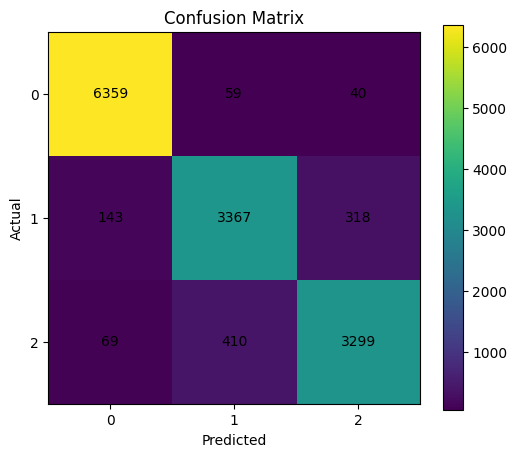

In [10]:
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1, 2], ["0", "1", "2"])
plt.yticks([0, 1, 2], ["0", "1", "2"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Baseline Model Analysis

## Overall Performance

The model performs well across all three classes, indicating that TF-IDF + Logistic Regression is a strong baseline for this task.

- Macro F1 Score: ~0.914
- Accuracy: ~0.93

---

## Per-Class Performance

### Class 0 (Not Review)

The model performs extremely well on class 0, suggesting that non-review texts are relatively easy to distinguish from reviews.

- Precision: 0.97
- Recall: 0.98
- F1: 0.98

---

### Class 1 (Positive)

Performance is lower compared to class 0, indicating some confusion with other classes.

- Precision: 0.88
- Recall: 0.88
- F1: 0.88

---

### Class 2 (Negative)

Similar to class 1, with slightly lower recall, indicating that some negative reviews are misclassified.

- Precision: 0.90
- Recall: 0.87
- F1: 0.89

---

## From the Confusion Matrix...

The model is very good at detecting whether a text is a review, also, the harder task is distinguishing sentiment (positive vs negative)

- Most errors occur between:
  - Class 1 (Positive) and Class 2 (Negative)

- Very few errors occur between:
  - Class 0 and the other classes

---

# 6. Error Analysis

In [11]:
# Find misclassified examples
errors = X_val[val_preds != y_val]
true_labels = y_val[val_preds != y_val]
pred_labels = val_preds[val_preds != y_val]

error_df = pd.DataFrame({
    "text": errors,
    "true": true_labels,
    "pred": pred_labels
})

error_df.head(10)

#Print errors:
for i, row in error_df.head(5).iterrows():
    print(f"\nTRUE: {row['true']} | PRED: {row['pred']}\n")
    print(row["text"][:500])


TRUE: 2 | PRED: 1

The 1930' were a golden age of Los Angeles with its film industry and great potential of various other possibilities to become rich and famous and happy. People were arriving there hoping to fulfill their dreams. Expecting open arms and welcoming offers there were only a few who managed to succeed and find their way to stardom, majority then condemned to live starving, disillusioned and unwanted, searching for a bit of respect in dirty bars and nasty hotel rooms. <br /><br />Young Italian-Americ

TRUE: 2 | PRED: 1

I saw this film as a sneak preview before the Venice opening at the Telluride Film Festival. Your reaction to it will largely depend on your attitude about respecting the text of Shakespeare. On the plus side: Pacino gives a very good performance indeed as Shylock; Lynn Collins is a fine Portia; and the film has a sumptuous look. <br /><br />The negatives are predictable. "The Merchant of Venice" is arguably the most difficult of all of Shakespeare's play

## Error Analysis 

### Observed Error Patterns

#### 1) Negative to Predicted Positive (2 to 1)
Many errors show mixed sentiment:
- Texts contain both praise and criticism
- Formal tone with negatives
- Domain-specific critiques that lack negative words

Perhaps the model may rely on isolated positive words and miss the overall negative tone.

---

#### 2) Positive to Predicted Negative (1 to 2)
- Strong emotional or exaggerated language (punctuation or caps)
- Informal grammar

The model may misinterpret intensity/noise as negativity or fail to capture positive emphasis.

---

#### 3) Review to Predicted Not Review (2 to 0)
- Some reviews lack explicit movie-related keywords (“movie”, “film”)

The model is relying on domain keywords to detect reviews.

---

# 7. Model Improvement

## 7.1 Build the Model (Again)

In [12]:
#For the improvement I used trigrams and filter frequent terms (max_df)
model_2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.9
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model_2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 7.2 Model Evaluation

In [13]:
preds_2 = model_2.predict(X_val)

f1_2 = f1_score(y_val, preds_2, average="macro")
print(" Macro F1:", f1_2)

print("\nReport:\n")
print(classification_report(y_val, preds_2))

 Macro F1: 0.9138304921445254

Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      6458
           1       0.88      0.88      0.88      3828
           2       0.90      0.87      0.89      3778

    accuracy                           0.93     14064
   macro avg       0.92      0.91      0.91     14064
weighted avg       0.93      0.93      0.93     14064



## Results

Unfortunately the extended n-gram model did not improve over the baseline. The difference is very small, but the baseline remains slightly better. This suggests that adding trigrams may have introduced additional sparse features without improving generalization.

- Baseline Macro F1: 0.9141
- Extended n-gram Macro F1: 0.9138

I will stick with the baseline model in this case.


# 8. Model Selection

In [14]:
final_model = model

#Train the model

X_full = train["TEXT"]
y_full = train["LABEL"]
X_test = test["TEXT"]

final_model.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# 9. Output

In [17]:
#Predictions

test_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "ID": test["ID"],
    "LABEL": test_predictions
})

submission.to_csv("../outputs/submission.csv", index=False)

submission.head()

,ID,LABEL
0,1087873697464833975,1
1,5853461517618045821,1
2,1225516091890726770,2
3,11795874926011119457,0
4,15956464546963841646,0
